# Has the Intensity and Frequency of Extreme Rainfall Events in the Philippines Increased (1981–Present), and Is This Trend Spatially Correlated with Western Pacific Sea Surface Temperature Anomalies? #

## Scientific Question & Hypothesis ##
**Question:** 

Has the intensity and frequency of extreme rainfall events over the Philippines increased between 1981 and the present day, and is this trend spatially correlated with sea surface temperature (SST) anomalies in the Western Pacific driven by ENSO variability?

**Hypothesis:** 

Grid cell level trends in extreme rainfall metrics (days where precipitation > 100 mm, annual maximum daily precipitation) show a statistically significant increasing signal over the Philippine domain.

Yearly variability of Philippine rainfall extremes is negatively correlated with the Niño 3.4 index; La Niña years drive wetter extremes over the Philippines, while El Niño years suppress them.

## Datasets ##
CHIRPS Daily v2.0, UCSB Climate Hazards Group, Daily precipitation (mm/day), 0.05°, OPeNDAP / HTTP, NOAA ERSST v5, NOAA NCEI, Sea surface temperature (°C), 2°, OPeNDAP / THREDDS

In [10]:
# Setup libraries
import os
os.environ['PROJ_LIB'] = '/opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj'
import numpy as np
import xarray as xr 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Define the Philippines bounding box
LON_MIN, LON_MAX = 116.0, 127.5
LAT_MIN, LAT_MAX =   4.5,  21.5

# Define the  Niño 3.4 box
NINO34_LON_MIN, NINO34_LON_MAX = 190.0, 240.0   
NINO34_LAT_MIN, NINO34_LAT_MAX =  -5.0,   5.0

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load CHIRPS Daily Rainfall — Philippine Domain

In [11]:
# Open CHIRPS over OPENDAP
CHIRPS_URL = (
    'https://iridl.ldeo.columbia.edu/SOURCES/.UCSB/.CHIRPS/.v2p0/.daily-improved'
    '/.global/.0p25/.prcp/dods'
)

print('Opening CHIRPS dataset via OPeNDAP …')
print('(This may take a moment — data is streamed directly from the IRI server)')

try:
    ds_chirps_raw = xr.open_dataset(CHIRPS_URL, engine='pydap',
                                    chunks={'T': 365})
    print('Dataset opened:', ds_chirps_raw)
except Exception as e:
    print(f'OPeNDAP open failed: {e}')
    print('Falling back to direct HTTP download for a single year as demonstration …')
    ds_chirps_raw = None

Opening CHIRPS dataset via OPeNDAP …
(This may take a moment — data is streamed directly from the IRI server)
Dataset opened: <xarray.Dataset> Size: 38GB
Dimensions:  (Y: 400, X: 1440, T: 16526)
Coordinates:
  * Y        (Y) float32 2kB 49.88 49.62 49.38 49.12 ... -49.38 -49.62 -49.88
  * X        (X) float32 6kB -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * T        (T) float32 66kB 2.445e+06 2.445e+06 ... 2.461e+06 2.461e+06
Data variables:
    prcp     (T, Y, X) float32 38GB dask.array<chunksize=(365, 400, 1440), meta=np.ndarray>
Attributes:
    Conventions:  IRIDL


In [12]:
# Clip global CHIRPS array to Philippines bounding box
import pandas as pd
import numpy as np
if ds_chirps_raw is not None:
    ds_chirps_ph = ds_chirps_raw.sel(X=slice(LON_MIN, LON_MAX), Y=slice(LAT_MAX, LAT_MIN))
    t_julian = ds_chirps_ph['T'].values.astype('float64')
    t_datetime = pd.to_datetime((t_julian - 2440587.5) * 86400.0, unit='s')
    ds_chirps_ph = ds_chirps_ph.assign_coords(T=('T', t_datetime))
    ds_chirps_ph = ds_chirps_ph.sel(T=slice('1991-01-01', '2022-12-31'))
    ds_chirps_ph = ds_chirps_ph.rename({'X': 'longitude', 'Y': 'latitude', 'T': 'time'})
    precip_var = 'prcp'
    print('Subset dataset successfully:', ds_chirps_ph)

Subset dataset successfully: <xarray.Dataset> Size: 146MB
Dimensions:    (latitude: 68, longitude: 46, time: 11688)
Coordinates:
  * latitude   (latitude) float32 272B 21.38 21.12 20.88 ... 5.125 4.875 4.625
  * longitude  (longitude) float32 184B 116.1 116.4 116.6 ... 126.9 127.1 127.4
  * time       (time) datetime64[ns] 94kB 1991-01-01T12:00:00 ... 2022-12-31T...
Data variables:
    prcp       (time, latitude, longitude) float32 146MB dask.array<chunksize=(363, 68, 46), meta=np.ndarray>
Attributes:
    Conventions:  IRIDL


In [13]:
# Pulls precipitatin data, and masks missing values
rain = ds_chirps_ph[precip_var]

rain = rain.where(rain >= 0)

print('Precipitation variable:', rain)
print(f'\nTime range: {rain.time.values[0]} → {rain.time.values[-1]}')
print(f'Lat range:  {float(rain.latitude.min()):.2f} – {float(rain.latitude.max()):.2f}')
print(f'Lon range:  {float(rain.longitude.min()):.2f} – {float(rain.longitude.max()):.2f}')
print(f'Max daily rainfall in record: {float(rain.max()):.1f} mm')

Precipitation variable: <xarray.DataArray 'prcp' (time: 11688, latitude: 68, longitude: 46)> Size: 146MB
dask.array<where, shape=(11688, 68, 46), dtype=float32, chunksize=(365, 68, 46), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 272B 21.38 21.12 20.88 ... 5.125 4.875 4.625
  * longitude  (longitude) float32 184B 116.1 116.4 116.6 ... 126.9 127.1 127.4
  * time       (time) datetime64[ns] 94kB 1991-01-01T12:00:00 ... 2022-12-31T...
Attributes: (12/13)
    pointwidth:      1.0
    units:           mm/day
    standard_name:   lwe_precipitation_rate
    long_name:       precipitation
    expires:         1777593600
    CS:              0.0
    ...              ...
    CE:              100.0
    scale_max:       100.0
    maxncolor:       254
    colorscalename:  prcp_dailyrate_max100_smooth
    colormap:        ['13882323', '16777215', '16777215', '16777184', '6', '1...
    scale_min:       0.0

Time range: 1991-01-01T12:00:00.000000000 → 2022-12-31T12:00:00.00

## 2. Compute Annual Extreme Rainfall Metrics

In [14]:
print('Computing annual extreme rainfall metrics …')

# Rx1day: maximum single day precipitation each year
rx1day = rain.resample(time='1YE').max(dim='time')
rx1day.name = 'Rx1day'
rx1day.attrs['long_name'] = 'Annual maximum 1-day precipitation'
rx1day.attrs['units'] = 'mm'

# R100mm: count of days each year where precip >= 100 mm
r100 = (rain >= 100.0).resample(time='1YE').sum(dim='time')
r100.name = 'R100mm'
r100.attrs['long_name'] = 'Annual count of days with precip >= 100 mm'
r100.attrs['units'] = 'days/year'

print('Rx1day:', rx1day)
print('R100mm:', r100)

Computing annual extreme rainfall metrics …
Rx1day: <xarray.DataArray 'Rx1day' (time: 32, latitude: 68, longitude: 46)> Size: 400kB
dask.array<stack, shape=(32, 68, 46), dtype=float32, chunksize=(1, 68, 46), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 272B 21.38 21.12 20.88 ... 5.125 4.875 4.625
  * longitude  (longitude) float32 184B 116.1 116.4 116.6 ... 126.9 127.1 127.4
  * time       (time) datetime64[ns] 256B 1991-12-31 1992-12-31 ... 2022-12-31
Attributes: (12/13)
    pointwidth:      1.0
    units:           mm
    standard_name:   lwe_precipitation_rate
    long_name:       Annual maximum 1-day precipitation
    expires:         1777593600
    CS:              0.0
    ...              ...
    CE:              100.0
    scale_max:       100.0
    maxncolor:       254
    colorscalename:  prcp_dailyrate_max100_smooth
    colormap:        ['13882323', '16777215', '16777215', '16777184', '6', '1...
    scale_min:       0.0
R100mm: <xarray.DataArray 'R10

In [15]:
# Pull year coordinate for time axis
years_chirps = rx1day.time.dt.year.values
print('Years in extreme metrics:', years_chirps[0], '–', years_chirps[-1],
      f'({len(years_chirps)} years)')

Years in extreme metrics: 1991 – 2022 (32 years)


## 3. Linear Trend Analysis — Grid Cell Level

In [17]:
def lintrend_map(da):
    """
    Compute OLS slope (per year) and p-value at every grid cell.
    Returns (slope_da, pval_da) with same lat/lon coords as input.
    """
    t = np.arange(len(da.time))  

    vals = da.values  
    nt, nlat, nlon = vals.shape
    vals_2d = vals.reshape(nt, -1)  

    slopes = np.full(nlat * nlon, np.nan)
    pvals  = np.full(nlat * nlon, np.nan)

    for i in range(nlat * nlon):
        col = vals_2d[:, i]
        mask = ~np.isnan(col)
        if mask.sum() < 10:   
            continue
        res = stats.linregress(t[mask], col[mask])
        slopes[i] = res.slope
        pvals[i]  = res.pvalue

    slope_2d = slopes.reshape(nlat, nlon)
    pval_2d  = pvals.reshape(nlat, nlon)

    lat = da.latitude.values
    lon = da.longitude.values
    slope_da = xr.DataArray(slope_2d, dims=['latitude','longitude'],
                            coords={'latitude': lat, 'longitude': lon})
    pval_da  = xr.DataArray(pval_2d,  dims=['latitude','longitude'],
                            coords={'latitude': lat, 'longitude': lon})
    return slope_da, pval_da


print('Computing grid-cell OLS trends for Rx1day …')
slope_rx1day, pval_rx1day = lintrend_map(rx1day)
slope_rx1day_dec = slope_rx1day * 10   

print('Computing grid-cell OLS trends for R100mm …')
slope_r100, pval_r100 = lintrend_map(r100)
slope_r100_dec = slope_r100 * 10       

print('Trend computation complete.')
print(f'  Median Rx1day trend: {float(slope_rx1day_dec.median()):.2f} mm/decade')
print(f'  Median R100mm trend: {float(slope_r100_dec.median()):.2f} days/decade')

Computing grid-cell OLS trends for Rx1day …
Computing grid-cell OLS trends for R100mm …
Trend computation complete.
  Median Rx1day trend: -0.08 mm/decade
  Median R100mm trend: 0.00 days/decade


## 4. Load ERSST v5 and Compute Niño 3.4 Index 

In [18]:
import urllib.request, os

ERSST_URL = 'https://downloads.psl.noaa.gov/Datasets/noaa.ersst.v5/sst.mnmean.nc'
ersst_path = '/tmp/ersst_v5_sst.mnmean.nc'

if not os.path.exists(ersst_path):
    print('Downloading ERSST v5 ...')
    urllib.request.urlretrieve(ERSST_URL, ersst_path)

ds_sst = xr.open_dataset(ersst_path)
sst_var = 'sst'
print('ERSST loaded:', ds_sst)

ERSST loaded: <xarray.Dataset> Size: 133MB
Dimensions:    (lat: 89, lon: 180, time: 2068, nbnds: 2)
Coordinates:
  * lat        (lat) float32 356B 88.0 86.0 84.0 82.0 ... -84.0 -86.0 -88.0
  * lon        (lon) float32 720B 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-04-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 33kB ...
    sst        (time, lat, lon) float32 133MB ...
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...               

In [19]:
# Clip to Niño 3.4 region and compute index
sst = ds_sst[sst_var]
sst = sst.sortby('lat') 

# Handle 0–360 vs -180–180 longitude and choose right slice for the Niño 3.4 box
if float(sst.lon.min()) < 0:
    nino_lon_slice = slice(-170, -120)
else:
    nino_lon_slice = slice(NINO34_LON_MIN, NINO34_LON_MAX)

sst_nino34 = sst.sel(
    lon=nino_lon_slice,
    lat=slice(NINO34_LAT_MIN, NINO34_LAT_MAX)
)

# Spatially average the box to get monthly Niño 3.4 time series
nino34_monthly = sst_nino34.mean(dim=['lat', 'lon'])

# Compute a 1981-2010 monthly climatology and subtract it to get anomalies
baseline = nino34_monthly.sel(time=slice('1981-01-01', '2010-12-31'))
clim = baseline.groupby('time.month').mean('time')
nino34_anom = nino34_monthly.groupby('time.month') - clim

# Apply a 3 month rolling mean, ONI according to NASA
nino34_oni = nino34_anom.rolling(time=3, center=True, min_periods=2).mean()

# Tri to CHIRPS years and resample to annual means so it can be paired w annual rainfall metrics
yr_start = int(years_chirps[0])
yr_end   = int(years_chirps[-1])
nino34_annual = (
    nino34_oni
    .sel(time=slice(f'{yr_start}-01-01', f'{yr_end}-12-31'))
    .resample(time='1YE').mean()
)
years_sst = nino34_annual.time.dt.year.values

print('Niño 3.4 annual ONI computed.')
print(f'  Range: {float(nino34_annual.min()):.2f} to {float(nino34_annual.max()):.2f} °C')
print(f'  Years: {years_sst[0]} – {years_sst[-1]}')

Niño 3.4 annual ONI computed.
  Range: -1.23 to 1.52 °C
  Years: 1991 – 2022


## 5. Correlation: Niño 3.4 vs. Philippines Area-Mean Rainfall Extremes

In [20]:
# Take a weighted spatial mean of Rx1day and R100mm to get Philippines avg annual time series with area weighting
weights = np.cos(np.deg2rad(rx1day.latitude))

rx1day_ts = rx1day.weighted(weights).mean(dim=['latitude','longitude']).values
r100_ts   = r100.weighted(weights).mean(dim=['latitude','longitude']).values

# Align years between CHIRPS and ERSST
common_years = np.intersect1d(years_chirps, years_sst)
idx_chirps = np.isin(years_chirps, common_years)
idx_sst    = np.isin(years_sst,    common_years)

rx1day_aligned = rx1day_ts[idx_chirps]
r100_aligned   = r100_ts[idx_chirps]
oni_aligned    = nino34_annual.values[idx_sst]

# Pearson correlation of ONI series w each rainfall extreme
r_rx1day, p_rx1day = stats.pearsonr(oni_aligned, rx1day_aligned)
r_r100,   p_r100   = stats.pearsonr(oni_aligned, r100_aligned)

In [21]:
print(f'Niño 3.4 × Rx1day:  r = {r_rx1day:.3f}, p = {p_rx1day:.4f}')
print(f'Niño 3.4 × R100mm:  r = {r_r100:.3f},   p = {p_r100:.4f}')

Niño 3.4 × Rx1day:  r = 0.066, p = 0.7178
Niño 3.4 × R100mm:  r = -0.317,   p = 0.0767


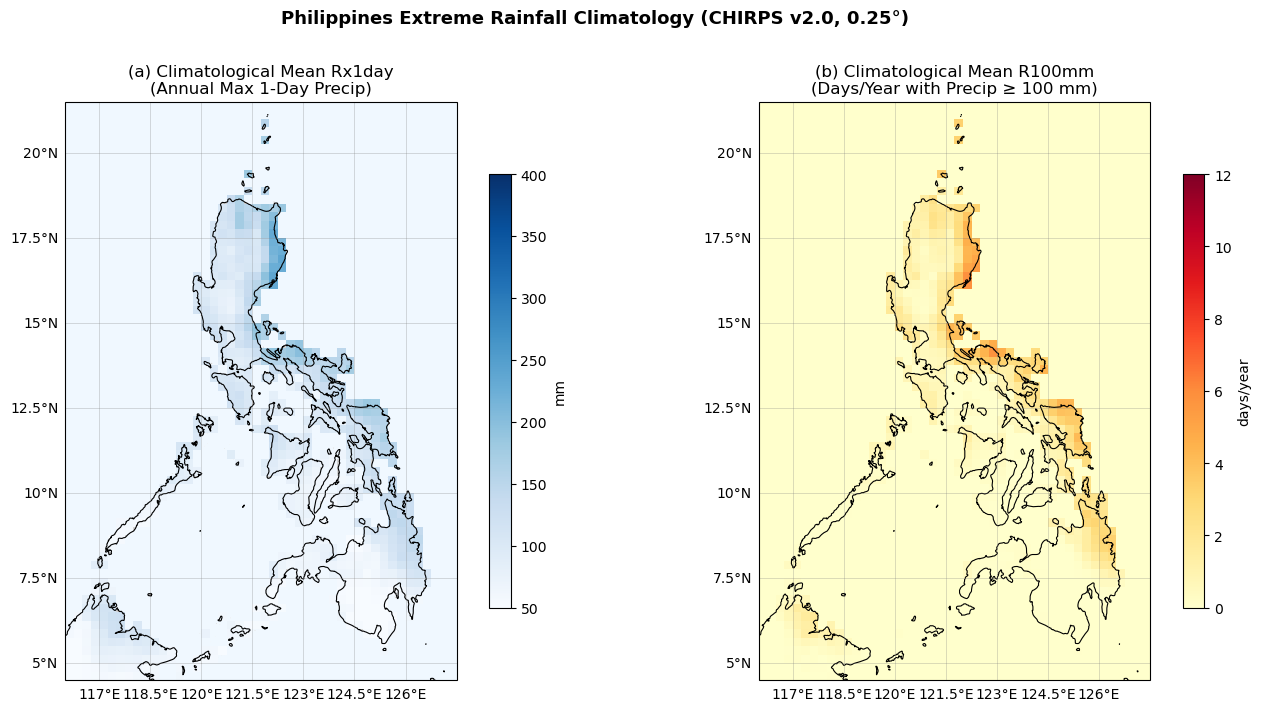

Figure 1 saved.


In [22]:
# FIGURE 1: Climatological mean spatial maps 
# Use matplotlib so each axis is a geographic map
# Philippine extreme rainfall on average
# wet hotspots are deeper colors, found in areas that face NE monsoon and Pacific tropical cyclones
# drier areas are lighter colors, found in inner valleys or western leeward sides

fig, axes = plt.subplots(1, 2, figsize=(14, 7),
                          subplot_kw={'projection': ccrs.PlateCarree()})

proj = ccrs.PlateCarree()
extent = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]

def add_map_features(ax):
    ax.set_extent(extent, crs=proj)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='aliceblue', zorder=0)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

# Panel A: mean single-day maximum precipitation each year Rx1day 
# Baseline map for Philippine extreme rainfall on average
ax = axes[0]
clim_rx1day = rx1day.mean('time')
im = clim_rx1day.plot(
    ax=ax, transform=proj, cmap='Blues', add_colorbar=False,
    vmin=50, vmax=400
)
cb = plt.colorbar(im, ax=ax, shrink=0.75, label='mm')
add_map_features(ax)
ax.set_title('(a) Climatological Mean Rx1day\n(Annual Max 1-Day Precip)', fontsize=12)

# Panel B: mean count of days each year where precip >= 100 mm R100mm
ax = axes[1]
clim_r100 = r100.mean('time')
im2 = clim_r100.plot(
    ax=ax, transform=proj, cmap='YlOrRd', add_colorbar=False,
    vmin=0, vmax=12
)
cb2 = plt.colorbar(im2, ax=ax, shrink=0.75, label='days/year')
add_map_features(ax)
ax.set_title('(b) Climatological Mean R100mm\n(Days/Year with Precip ≥ 100 mm)', fontsize=12)

fig.suptitle('Philippines Extreme Rainfall Climatology (CHIRPS v2.0, 0.25°)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_climatology.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

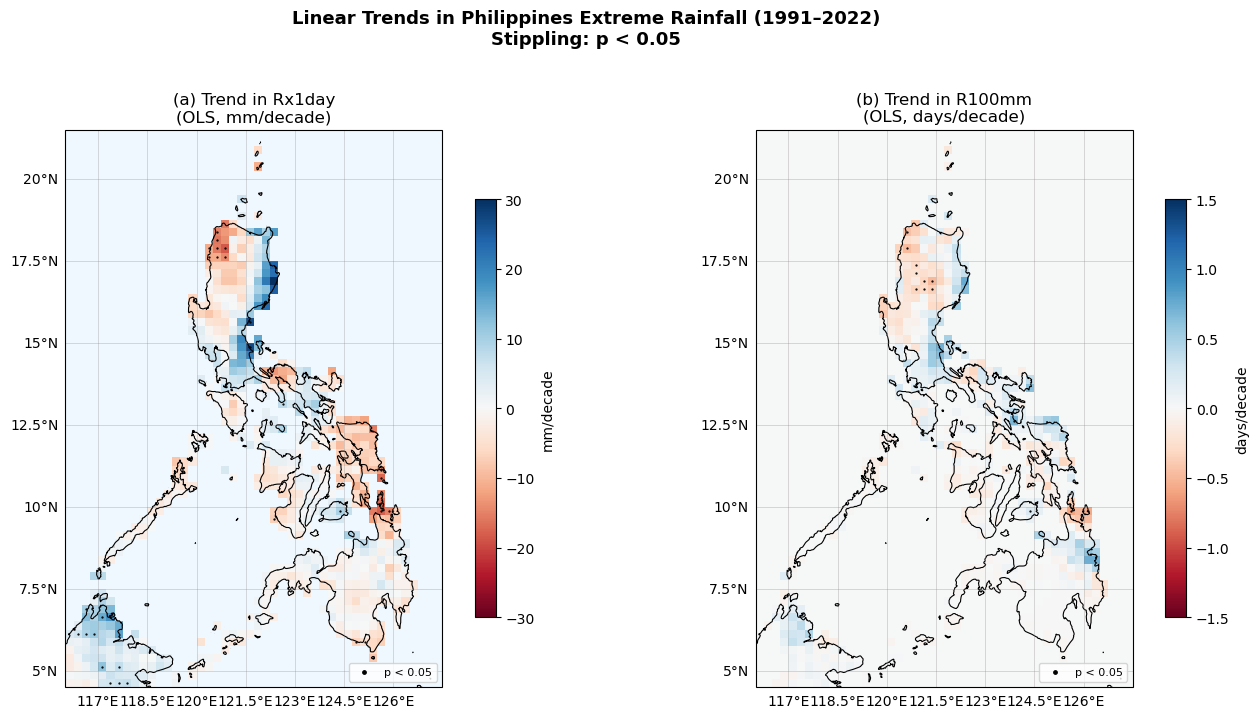

Figure 2 saved.


In [23]:
# FIGURE 2: Spatial trend maps with significance stippling 
# Hypothesis 1: Grid cell level trends in extreme rainfall metrics (days where precipitation > 100 mm, annual maximum daily precipitation) show a statistically significant increasing signal over the Philippine domain.
# If the country were getting more extreme rain uniformly, the maps would be dominated red. Patchy patterns mean the trend is not increasing the same everywhere
fig, axes = plt.subplots(1, 2, figsize=(14, 7),
                          subplot_kw={'projection': ccrs.PlateCarree()})

ALPHA = 0.05   

def plot_trend_map(ax, slope_da, pval_da, title, label,
                   vmin, vmax, cmap):
    add_map_features(ax)
    im = ax.pcolormesh(
        slope_da.longitude, slope_da.latitude, slope_da.values,
        transform=proj, cmap=cmap, vmin=vmin, vmax=vmax
    )
    plt.colorbar(im, ax=ax, shrink=0.75, label=label)
    
    sig = pval_da.values < ALPHA
    lon2d, lat2d = np.meshgrid(slope_da.longitude, slope_da.latitude)
    ax.scatter(
        lon2d[sig], lat2d[sig],
        s=1.5, c='k', marker='.', transform=proj,
        label=f'p < {ALPHA}'
    )
    ax.set_title(title, fontsize=12)
    ax.legend(loc='lower right', fontsize=8, markerscale=4)

plot_trend_map(
    axes[0], slope_rx1day_dec, pval_rx1day,
    title='(a) Trend in Rx1day\n(OLS, mm/decade)',
    label='mm/decade',
    vmin=-30, vmax=30, cmap='RdBu'
)

plot_trend_map(
    axes[1], slope_r100_dec, pval_r100,
    title='(b) Trend in R100mm\n(OLS, days/decade)',
    label='days/decade',
    vmin=-1.5, vmax=1.5, cmap='RdBu'
)

fig.suptitle(
    f'Linear Trends in Philippines Extreme Rainfall ({years_chirps[0]}–{years_chirps[-1]})\n'
    'Stippling: p < 0.05',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('fig2_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

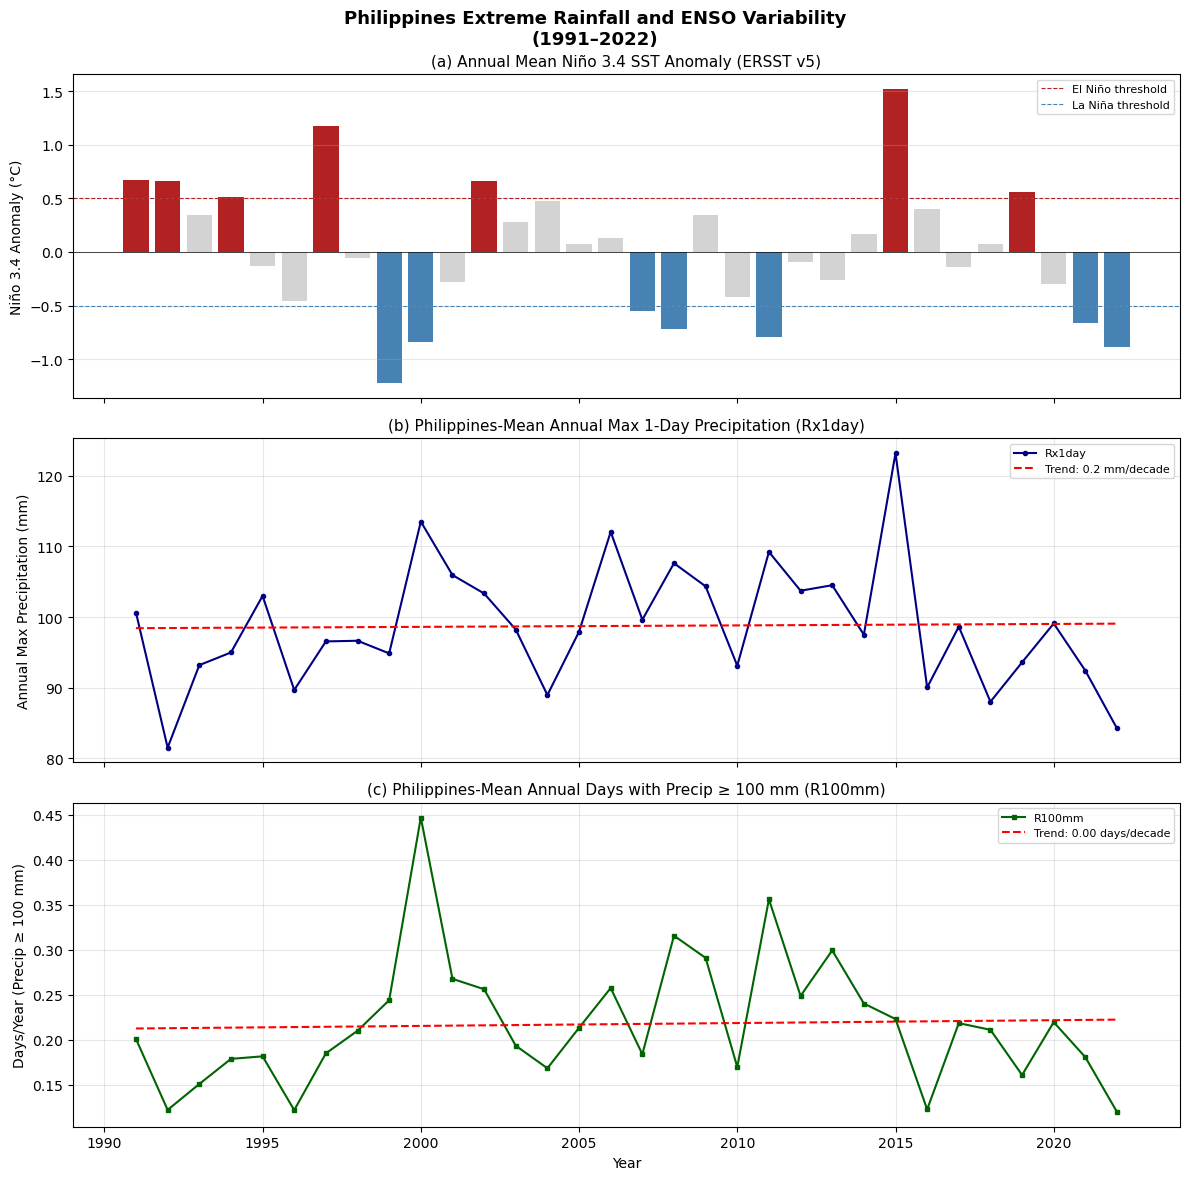

Figure 3 saved.


In [24]:
# FIGURE 3: Time series of Philippines-mean extremes vs. Niño 3.4 
# Hypothesis 2: Yearly variability of Philippine rainfall extremes is negatively correlated with the Niño 3.4 index; La Niña years drive wetter extremes over the Philippines, while El Niño years suppress them.
# 
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Panel 1: Niño 3.4 ONI
# Plots annual Niño 3.4 ONI as bar chart, red when ONI > 0.5 C (El Niño), blue when ONI < 0.5 C (La Niña)
ax = axes[0]
oni_vals = nino34_annual.values[idx_sst]
ax.bar(common_years, oni_vals,
       color=np.where(oni_vals >= 0.5, 'firebrick',
               np.where(oni_vals <= -0.5, 'steelblue', 'lightgray')),
       edgecolor='none')
ax.axhline(0.5,  color='firebrick', lw=0.8, ls='--', label='El Niño threshold')
ax.axhline(-0.5, color='steelblue', lw=0.8, ls='--', label='La Niña threshold')
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Niño 3.4 Anomaly (°C)', fontsize=10)
ax.set_title('(a) Annual Mean Niño 3.4 SST Anomaly (ERSST v5)', fontsize=11)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Panel 2: Rx1day time series 
# Plots Philippines mean Rx1day series as a blue line
ax = axes[1]
ax.plot(common_years, rx1day_aligned, color='navy', lw=1.5, marker='o', ms=3,
        label='Rx1day')
# Add trend line
m, b = np.polyfit(common_years, rx1day_aligned, 1)
ax.plot(common_years, m * common_years + b, 'r--', lw=1.5,
        label=f'Trend: {m*10:.1f} mm/decade')
ax.set_ylabel('Annual Max Precipitation (mm)', fontsize=10)
ax.set_title('(b) Philippines-Mean Annual Max 1-Day Precipitation (Rx1day)', fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 3: R100mm time series 
# Plots Philippines mean R100mm series as a green line
ax = axes[2]
ax.plot(common_years, r100_aligned, color='darkgreen', lw=1.5, marker='s', ms=3,
        label='R100mm')
m2, b2 = np.polyfit(common_years, r100_aligned, 1)
ax.plot(common_years, m2 * common_years + b2, 'r--', lw=1.5,
        label=f'Trend: {m2*10:.2f} days/decade')
ax.set_ylabel('Days/Year (Precip ≥ 100 mm)', fontsize=10)
ax.set_title('(c) Philippines-Mean Annual Days with Precip ≥ 100 mm (R100mm)', fontsize=11)
ax.set_xlabel('Year', fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.suptitle('Philippines Extreme Rainfall and ENSO Variability\n'
             f'({common_years[0]}–{common_years[-1]})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

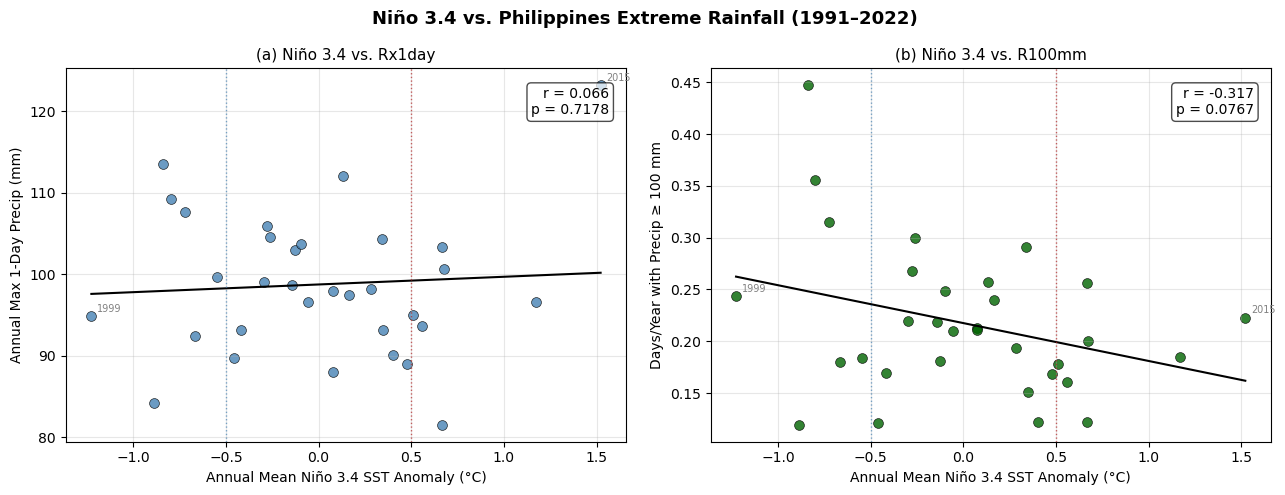

Figure 4 saved.


In [25]:
# FIGURE 4: Scatter plots — Niño 3.4 vs. extreme metrics 
# Rx1day vs. Niño 3.4 shows essentially no relationship (r ≈ 0.07, p ≈ 0.72), meaning the magnitude of the single wettest day each year is not tied to ENSO
# R100mm vs. Niño 3.4 is negatively correlated (r ≈ ‑0.32, p ≈ 0.08), in the hypothesized direction: La Niña years tend to bring more heavy‑rain days and El Niño years fewer, though the result is only marginally significant given the 32‑year record
# ENSO can modulate the frequency of extreme rainfall over the Philippines but not its peak intensity
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

def scatter_panel(ax, oni, metric, ylabel, title, r_val, p_val, color):
    ax.scatter(oni, metric, color=color, edgecolors='k', lw=0.5, s=50, alpha=0.8)
    # Regression line
    m, b = np.polyfit(oni, metric, 1)
    x_line = np.linspace(oni.min(), oni.max(), 100)
    ax.plot(x_line, m * x_line + b, 'k-', lw=1.5)
    # Label El Niño / La Niña regions
    ax.axvline(0.5,  color='firebrick', ls=':', lw=1, alpha=0.7)
    ax.axvline(-0.5, color='steelblue', ls=':', lw=1, alpha=0.7)
    ax.text(0.97, 0.95,
            f'r = {r_val:.3f}\np = {p_val:.4f}',
            transform=ax.transAxes,
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
    ax.set_xlabel('Annual Mean Niño 3.4 SST Anomaly (°C)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.3)
    # Annotate ENSO years
    for yr, o, m_val in zip(common_years, oni, metric):
        if abs(o) > 1.2:
            ax.annotate(str(yr), (o, m_val), textcoords='offset points',
                        xytext=(4, 3), fontsize=7, color='gray')

scatter_panel(
    axes[0], oni_aligned, rx1day_aligned,
    ylabel='Annual Max 1-Day Precip (mm)',
    title='(a) Niño 3.4 vs. Rx1day',
    r_val=r_rx1day, p_val=p_rx1day, color='steelblue'
)

scatter_panel(
    axes[1], oni_aligned, r100_aligned,
    ylabel='Days/Year with Precip ≥ 100 mm',
    title='(b) Niño 3.4 vs. R100mm',
    r_val=r_r100, p_val=p_r100, color='darkgreen'
)

fig.suptitle(
    f'Niño 3.4 vs. Philippines Extreme Rainfall ({common_years[0]}–{common_years[-1]})',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig4_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')